# 04 - Autoencoder

## Objective
Train autoencoder anomaly detection models for credit card fraud detection using a validation-based selection workflow.

- The autoencoder is trained only on normal training transactions. 
- Hyperparameters and thresholds are selected using the validation set. 
- The test set is reserved for final evaluation.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)

## Load Processed Data

In [2]:
data_path = Path("../outputs/results_corrected/creditcard_cleaned.pkl")
data = joblib.load(data_path)

X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

X_train_normal = X_train[y_train == 0]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("Normal training transactions:", X_train_normal.shape)

X_train: (198608, 30)
X_val: (42559, 30)
X_test: (42559, 30)
Normal training transactions: (198277, 30)


## Why Train Only on Normal Transactions?

- The autoencoder learns to reconstruct normal transaction behaviour. 
- Fraudulent transactions are expected to have larger reconstruction errors because they should be less similar to the normal training distribution.
- https://www.tensorflow.org/tutorials/generative/autoencoder 

In [3]:
def build_autoencoder(input_dim, bottleneck_size=6, dropout_rate=0.2, learning_rate=1e-3):
    input_layer = Input(shape=(input_dim,))

    encoder = Dense(24, activation="relu")(input_layer)
    encoder = Dropout(dropout_rate)(encoder)
    encoder = Dense(12, activation="relu")(encoder)
    bottleneck = Dense(bottleneck_size, activation="relu")(encoder)

    decoder = Dense(12, activation="relu")(bottleneck)
    decoder = Dropout(dropout_rate)(decoder)
    decoder = Dense(24, activation="relu")(decoder)
    output_layer = Dense(input_dim, activation="linear")(decoder)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
    )
    return model


def reconstruction_error(model, X):
    reconstructions = model.predict(X, verbose=0)
    return np.mean(np.square(X.values - reconstructions), axis=1)


def evaluate_anomaly_scores(model_name, y_true, anomaly_score, threshold, percentile=None):
    y_pred = (anomaly_score > threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "Model": model_name,
        "Percentile": percentile,
        "Threshold": threshold,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, anomaly_score),
        "PR_AUC": average_precision_score(y_true, anomaly_score),
        "TN": cm.ravel()[0],
        "FP": cm.ravel()[1],
        "FN": cm.ravel()[2],
        "TP": cm.ravel()[3],
    }

## Autoencoder Hyperparameter Experiments

- The experiments vary bottleneck size and dropout. 
- Each model is trained on normal training transactions only. 
- Candidate thresholds are derived from percentiles of normal training reconstruction error, then evaluated on the validation set.

In [4]:
experiment_configs = [
    {"name": "AE_bottleneck_4_dropout_0.1", "bottleneck_size": 4, "dropout_rate": 0.1},
    {"name": "AE_bottleneck_6_dropout_0.2", "bottleneck_size": 6, "dropout_rate": 0.2},
    {"name": "AE_bottleneck_8_dropout_0.2", "bottleneck_size": 8, "dropout_rate": 0.2},
    {"name": "AE_bottleneck_12_dropout_0.3", "bottleneck_size": 12, "dropout_rate": 0.3},
]

threshold_percentiles = [90, 92, 95, 97, 99]
input_dim = X_train.shape[1]

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

trained_autoencoders = {}
histories = {}
validation_rows = []

for config in experiment_configs:
    print("Training:", config["name"])
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = build_autoencoder(
        input_dim=input_dim,
        bottleneck_size=config["bottleneck_size"],
        dropout_rate=config["dropout_rate"],
    )

    history = model.fit(
        X_train_normal,
        X_train_normal,
        epochs=50,
        batch_size=256,
        validation_split=0.2,
        callbacks=[early_stop],
        shuffle=True,
        verbose=1,
    )

    train_loss = reconstruction_error(model, X_train_normal)
    val_loss = reconstruction_error(model, X_val)

    trained_autoencoders[config["name"]] = model
    histories[config["name"]] = history

    for percentile in threshold_percentiles:
        threshold = np.percentile(train_loss, percentile)
        validation_rows.append(
            evaluate_anomaly_scores(
                config["name"],
                y_val,
                val_loss,
                threshold,
                percentile=percentile,
            )
        )

autoencoder_validation_df = pd.DataFrame(validation_rows)
autoencoder_validation_df.sort_values(["F1", "PR_AUC", "Recall"], ascending=False).head(15)

Training: AE_bottleneck_4_dropout_0.1

Epoch 1/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8090 - val_loss: 0.6009
Epoch 2/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6012 - val_loss: 0.5194
Epoch 3/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5633 - val_loss: 0.4996
Epoch 4/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5428 - val_loss: 0.4812
Epoch 5/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5243 - val_loss: 0.4609
Epoch 6/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5109 - val_loss: 0.4506
Epoch 7/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5029 - val_loss: 0.4437
Epoch 8/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5011 - val_loss: 0.4406
Epoch 9/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4926 - val_loss: 0.4347
Epoch 10/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4926 - val_loss: 0.4349
Epoch 11/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4883 - val_loss: 0.4283
Epoch 12/50
6

,Model,Percentile,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
9,AE_bottleneck_6_dropout_0.2,99,3.613886,0.112621,0.816901,0.197952,0.962743,0.275695,42031,457,13,58
14,AE_bottleneck_8_dropout_0.2,99,3.381949,0.109228,0.816901,0.192691,0.961575,0.302107,42015,473,13,58
4,AE_bottleneck_4_dropout_0.1,99,1.990264,0.107407,0.816901,0.189853,0.958416,0.456596,42006,482,13,58
19,AE_bottleneck_12_dropout_0.3,99,4.547708,0.099206,0.704225,0.173913,0.956823,0.253068,42034,454,21,50
3,AE_bottleneck_4_dropout_0.1,97,1.134849,0.045194,0.887324,0.086007,0.958416,0.456596,41157,1331,8,63
13,AE_bottleneck_8_dropout_0.2,97,1.732556,0.043750,0.887324,0.083388,0.961575,0.302107,41111,1377,8,63
18,AE_bottleneck_12_dropout_0.3,97,1.968784,0.043416,0.859155,0.082656,0.956823,0.253068,41144,1344,10,61
8,AE_bottleneck_6_dropout_0.2,97,1.722077,0.043206,0.873239,0.082337,0.962743,0.275695,41115,1373,9,62
12,AE_bottleneck_8_dropout_0.2,95,1.416881,0.028457,0.901408,0.055172,0.961575,0.302107,40303,2185,7,64
17,AE_bottleneck_12_dropout_0.3,95,1.424515,0.027680,0.887324,0.053686,0.956823,0.253068,40275,2213,8,63


## Select Best Autoencoder on Validation Set

In [5]:
best_autoencoder_row = (
    autoencoder_validation_df
    .sort_values(["F1", "PR_AUC", "Recall"], ascending=False)
    .iloc[0]
)

best_autoencoder_name = best_autoencoder_row["Model"]
best_autoencoder_threshold = float(best_autoencoder_row["Threshold"])
best_autoencoder = trained_autoencoders[best_autoencoder_name]

print("Selected autoencoder:", best_autoencoder_name)
print("Selected threshold:", best_autoencoder_threshold)
best_autoencoder_row

Selected autoencoder: AE_bottleneck_6_dropout_0.2
Selected threshold: 3.61388581960664


Model         AE_bottleneck_6_dropout_0.2
Percentile                             99
Threshold                        3.613886
Precision                        0.112621
Recall                           0.816901
F1                               0.197952
ROC_AUC                          0.962743
PR_AUC                           0.275695
TN                                  42031
FP                                    457
FN                                     13
TP                                     58
Name: 9, dtype: object

## Training Curve for Selected Autoencoder

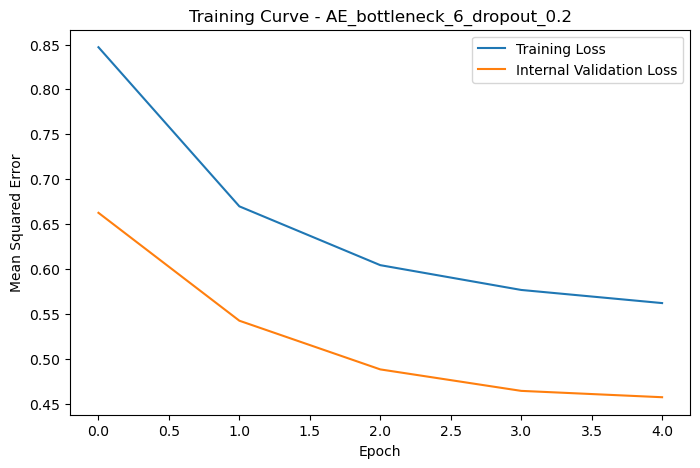

In [6]:
best_history = histories[best_autoencoder_name]

plt.figure(figsize=(8, 5))
plt.plot(best_history.history["loss"], label="Training Loss")
plt.plot(best_history.history["val_loss"], label="Internal Validation Loss")
plt.title(f"Training Curve - {best_autoencoder_name}")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

## Final Test Evaluation

The test set is used here only after the autoencoder configuration and threshold have been selected from validation results.

In [7]:
test_loss = reconstruction_error(best_autoencoder, X_test)
test_pred = (test_loss > best_autoencoder_threshold).astype(int)

print(f"===== {best_autoencoder_name} | threshold = {best_autoencoder_threshold:.6f} =====")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_pred))

autoencoder_test_result = evaluate_anomaly_scores(
    best_autoencoder_name,
    y_test,
    test_loss,
    best_autoencoder_threshold,
    percentile=best_autoencoder_row["Percentile"],
)

autoencoder_test_df = pd.DataFrame([autoencoder_test_result])
autoencoder_test_df

===== AE_bottleneck_6_dropout_0.2 | threshold = 3.613886 =====
              precision    recall  f1-score   support

           0     0.9996    0.9902    0.9949     42488
           1     0.1146    0.7606    0.1993        71

    accuracy                         0.9898     42559
   macro avg     0.5571    0.8754    0.5971     42559
weighted avg     0.9981    0.9898    0.9935     42559

Confusion matrix:
[[42071   417]
 [   17    54]]


,Model,Percentile,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,AE_bottleneck_6_dropout_0.2,99,3.613886,0.11465,0.760563,0.199262,0.93514,0.192112,42071,417,17,54


## Reconstruction Error Distribution

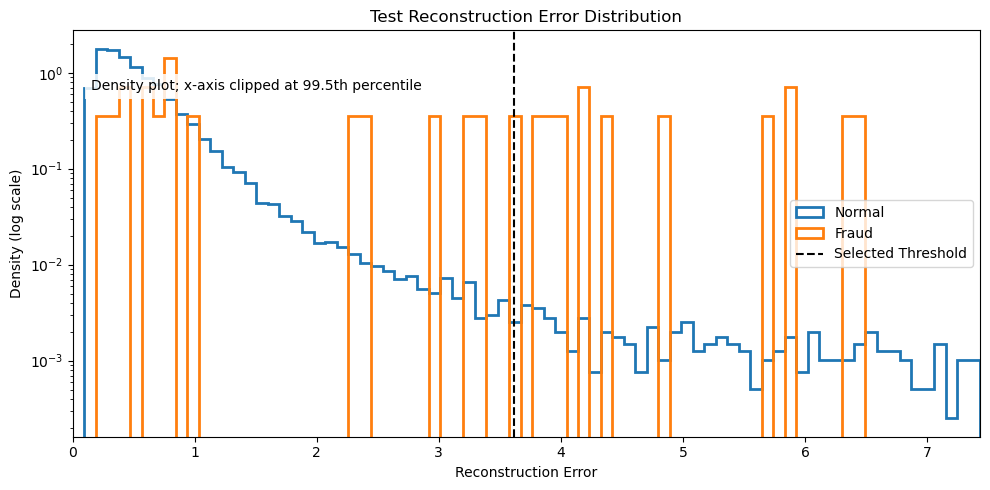

In [8]:
visible_limit = np.percentile(test_loss, 99.5)
bins = np.linspace(0, visible_limit, 80)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    test_loss[y_test == 0],
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Normal",
)
ax.hist(
    test_loss[y_test == 1],
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Fraud",
)
ax.axvline(best_autoencoder_threshold, linestyle="--", color="black", label="Selected Threshold")
ax.set_title("Test Reconstruction Error Distribution")
ax.set_xlabel("Reconstruction Error")
ax.set_ylabel("Density (log scale)")
ax.set_yscale("log")
ax.set_xlim(0, visible_limit)
ax.text(
    0.02,
    0.88,
    "Density plot; x-axis clipped at 99.5th percentile",
    transform=ax.transAxes,
    va="top",
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
)
ax.legend()
plt.tight_layout()
plt.show()


## ROC and Precision-Recall Curves

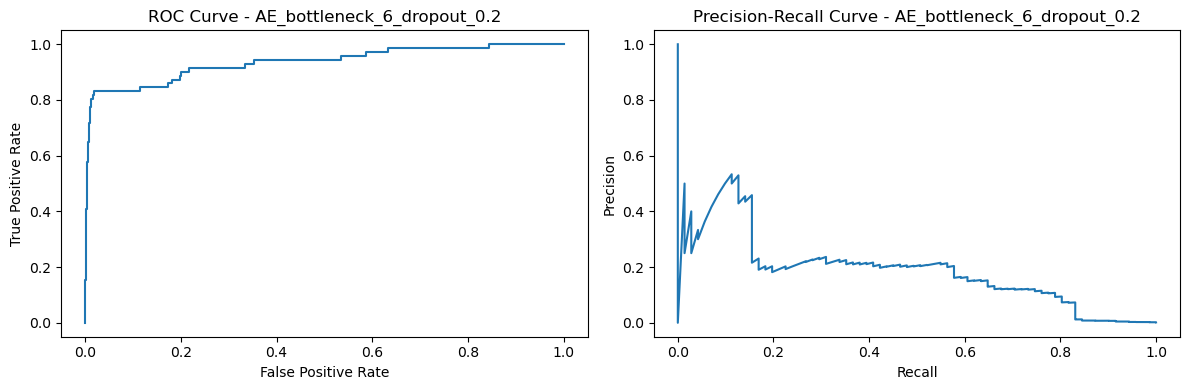

In [9]:
fpr, tpr, _ = roc_curve(y_test, test_loss)
precision, recall, _ = precision_recall_curve(y_test, test_loss)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr)
axes[0].set_title(f"ROC Curve - {best_autoencoder_name}")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

axes[1].plot(recall, precision)
axes[1].set_title(f"Precision-Recall Curve - {best_autoencoder_name}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.show()

## Compare Against Supervised Baseline

This comparison uses final test results saved by notebook 03. The aim is to decide whether the complex autoencoder improves the practical fraud detection trade-off or mainly provides a high-recall anomaly detection alternative.

In [10]:
baseline_test_path = Path("../outputs/results_corrected/baseline_test_results.csv")

if baseline_test_path.exists():
    baseline_test_df = pd.read_csv(baseline_test_path)
    comparison_df = pd.concat([baseline_test_df, autoencoder_test_df], ignore_index=True, sort=False)
    display(comparison_df[["Model", "Threshold", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "TN", "FP", "FN", "TP"]])
else:
    print("Run notebook 03 first to create baseline_test_results.csv.")

,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Random Forest - balanced,0.350000,0.925926,0.704225,0.800000,0.941271,0.815670,42484,4,21,50
1,AE_bottleneck_6_dropout_0.2,3.613886,0.114650,0.760563,0.199262,0.935140,0.192112,42071,417,17,54


## Saved Autoencoder and Comparison Figures

These plots save the autoencoder reconstruction-error distribution, ROC/PR curves, confusion matrix, and final comparison charts against the supervised baseline.


D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\ae_bottleneck_6_dropout_0_2_reconstruction_errors.png


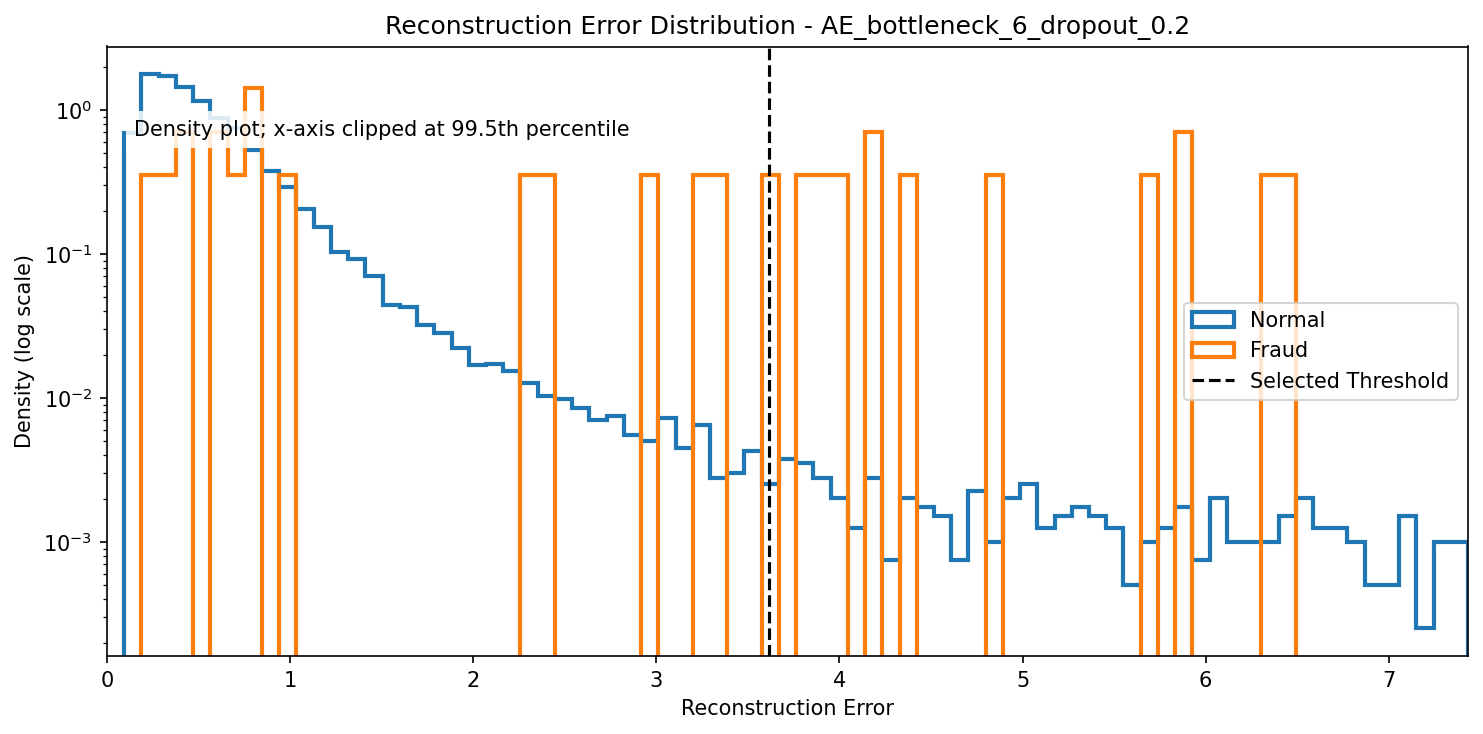

D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\ae_bottleneck_6_dropout_0_2_test_roc_pr_curves.png


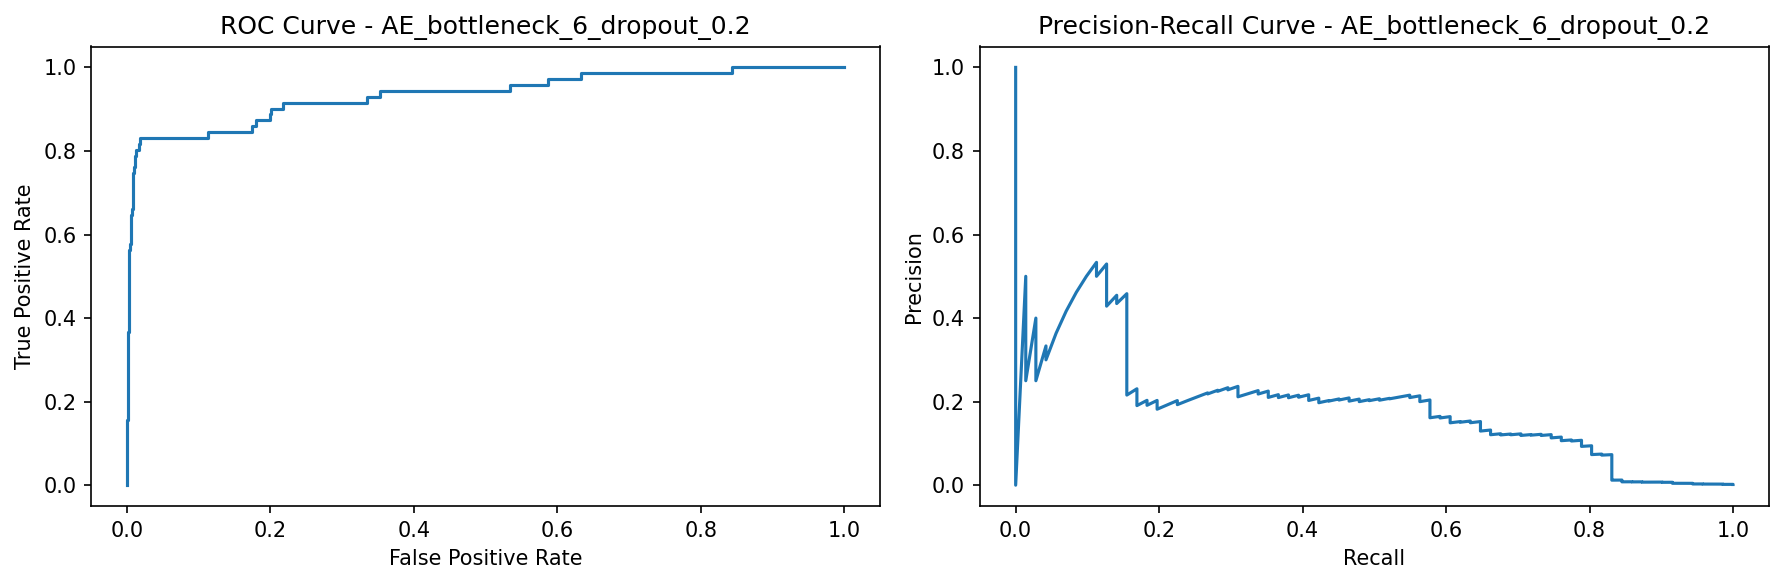

D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\ae_bottleneck_6_dropout_0_2_test_confusion_matrix.png


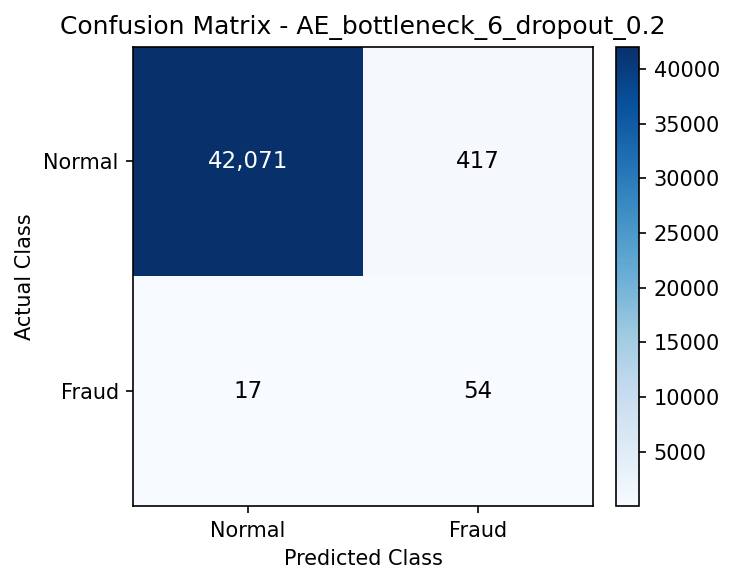

D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\model_final_metric_comparison.png


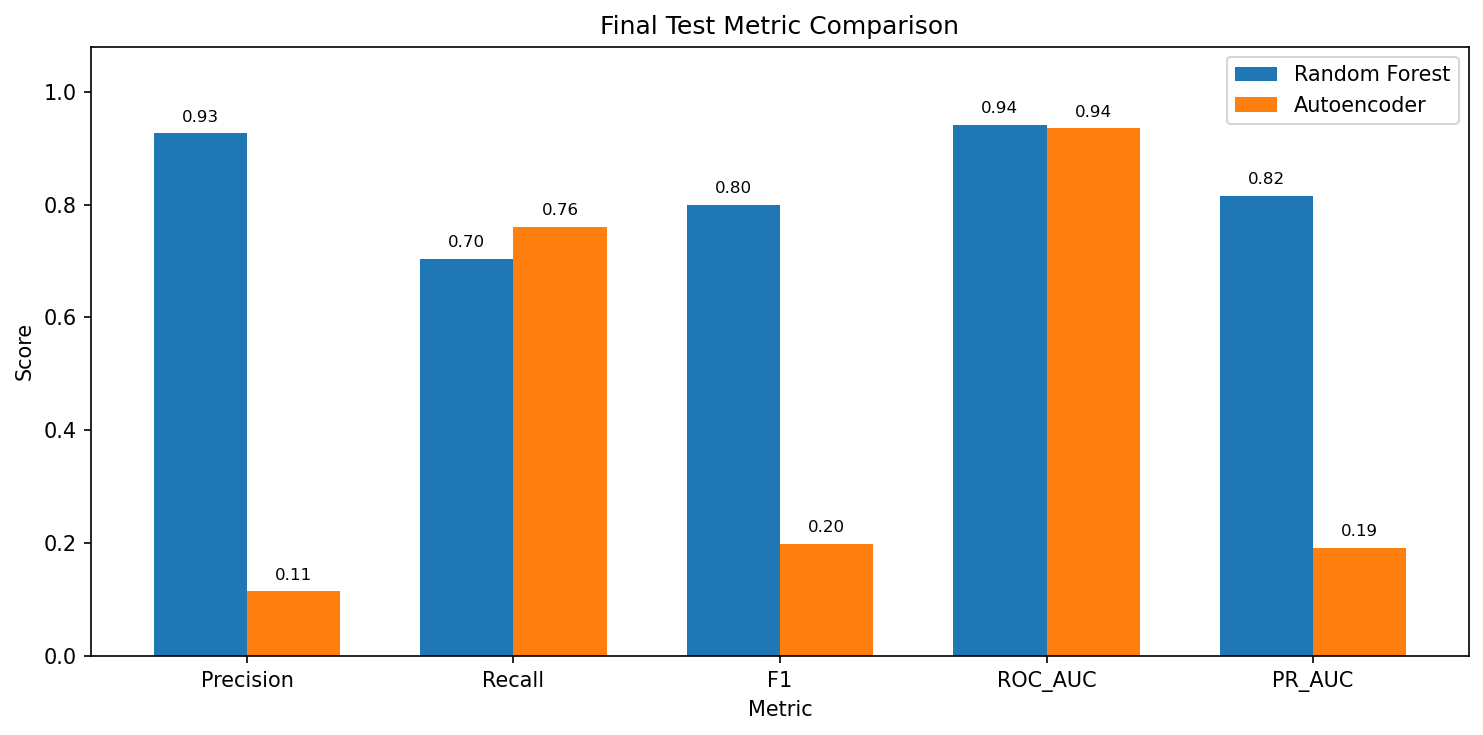

D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\model_final_detection_count_comparison.png


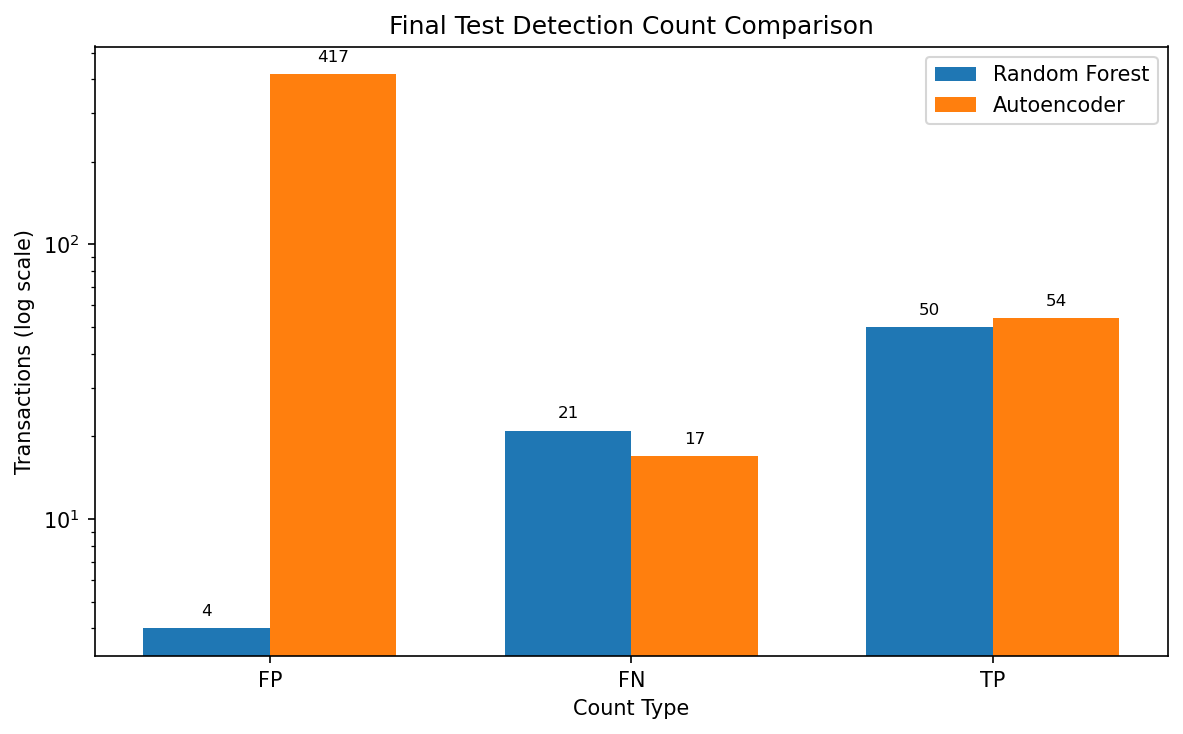

In [11]:
import sys
from IPython.display import Image, display

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.evaluation import (
    save_confusion_matrix_plot,
    save_error_count_comparison_plot,
    save_metric_comparison_plot,
    save_reconstruction_error_histogram,
    save_roc_pr_curves,
)

figures_dir = project_root / "outputs" / "figures"
saved_autoencoder_figures = [
    save_reconstruction_error_histogram(
        y_test,
        test_loss,
        best_autoencoder_threshold,
        best_autoencoder_name,
        figures_dir,
    ),
    save_roc_pr_curves(
        y_test,
        test_loss,
        best_autoencoder_name,
        figures_dir,
        "ae_bottleneck_6_dropout_0_2_test",
    ),
    save_confusion_matrix_plot(
        y_test,
        test_loss,
        best_autoencoder_threshold,
        best_autoencoder_name,
        figures_dir,
        "ae_bottleneck_6_dropout_0_2_test",
        anomaly=True,
    ),
]

if "comparison_df" in globals():
    saved_autoencoder_figures.extend(
        [
            save_metric_comparison_plot(comparison_df, figures_dir),
            save_error_count_comparison_plot(comparison_df, figures_dir),
        ]
    )

for figure_path in saved_autoencoder_figures:
    print(figure_path)
    display(Image(filename=str(figure_path)))


## Autoencoder Figure Interpretation

The training curve shows that the selected autoencoder learned a stable reconstruction pattern from normal transactions. The validation loss follows the training loss closely enough to support using the model for anomaly-score comparison.

The reconstruction-error plot uses density and a log-scaled y-axis because the dataset is highly imbalanced and reconstruction errors contain a few large outliers. The selected threshold catches some fraud cases, but the overlap between normal and fraud errors explains why the autoencoder has lower precision.

The autoencoder confusion matrix shows `54` true fraud detections and `17` missed fraud cases, but also `417` false positives. Compared with Random Forest, the autoencoder detects `4` extra fraud cases but creates many more false alarms.

The final metric and detection-count comparison plots show the main conclusion: the autoencoder is a useful complex anomaly-detection experiment with higher recall, but the Random Forest is the best practical final model because it has much higher precision, F1, and PR-AUC.


## Save Results

In [12]:
output_path = Path("../outputs/results_corrected")
output_path.mkdir(parents=True, exist_ok=True)

autoencoder_validation_df.to_csv(output_path / "autoencoder_validation_threshold_tuning.csv", index=False)
autoencoder_test_df.to_csv(output_path / "autoencoder_test_results.csv", index=False)

best_autoencoder.save(output_path / "autoencoder_best_model.keras")

joblib.dump(
    {
        "best_autoencoder_name": best_autoencoder_name,
        "best_autoencoder_threshold": best_autoencoder_threshold,
        "best_autoencoder_validation_row": best_autoencoder_row.to_dict(),
    },
    output_path / "autoencoder_selection.pkl",
)

print("Autoencoder model and corrected results saved to:", output_path)

Autoencoder model and corrected results saved to: ..\outputs\results_corrected


## Autoencoder Summary

- The autoencoder was trained only on normal training transactions.
- Architecture and threshold choices were selected using validation results, not test results.
- The selected autoencoder was `AE_bottleneck_6_dropout_0.2` with a 99th-percentile reconstruction-error threshold of `3.613886`.
- On the final test set, the selected autoencoder achieved precision `0.115`, recall `0.761`, F1 `0.199`, ROC-AUC `0.935`, and PR-AUC `0.192`.
- The final test confusion matrix was `TN = 42071`, `FP = 417`, `FN = 17`, and `TP = 54`.
- Compared with the Random Forest baseline, the autoencoder detects slightly more fraud cases (`54` vs `50`) but produces far more false positives (`417` vs `4`).
- Therefore,
# Final results
 the autoencoder is as a high-recall anomaly detection experiment, while the Random Forest is our strongest model.